# Análisis de los conjuntos de datos candidatos

**Grado en Ciencia e Ingeniería de Datos — Universidade da Coruña**

Este notebook explora los cinco conjuntos de datos de *credit scoring* que se barajan para el
TFG y **produce las cifras que después se recogen en el informe**: tamaño, número y tipo de
variables, definición y tasa de la variable objetivo, desequilibrio de clases, valores
perdidos, inventario de ficheros y las anomalías de codificación que habría que tratar antes
de modelar.

El apartado 7 reúne todo en una ficha por dataset, con los números ya formateados, para
trasladarlos al documento sin volver a calcular nada a mano.

---

## Índice

0. [Configuración](#s0)
1. [Give Me Some Credit](#s1)
2. [South German Credit](#s2)
3. [Default of Credit Card Clients (Taiwán)](#s3)
4. [Home Credit Default Risk](#s4)
5. [Lending Club](#s5)
6. [Tabla comparativa](#s6)
7. [Fichas para el informe](#s7)

> **Datos.** Los ficheros no se versionan: hay que descargarlos y dejarlos en `data/` con la
> estructura que indica el README. La lectura completa de Lending Club (1,7 GB) tarda algo
> menos de un minuto.

<a id="s0"></a>
## 0. Configuración

In [1]:
from __future__ import annotations

import re
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

pd.set_option("display.width", 120)
pd.set_option("display.max_columns", 40)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

# Rutas (relativas a la carpeta code/, desde la que se ejecuta el notebook)
DATA_DIR = Path("..") / "data"
DIR_GMSC = DATA_DIR / "GiveMeSomeCredit"
DIR_SGC = DATA_DIR / "south+german+credit+update"
DIR_TW = DATA_DIR / "default+of+credit+card+clients"
DIR_HC = DATA_DIR / "home-credit-default-risk"
DIR_LC = DATA_DIR / "lending-club"

print("Versiones utilizadas:")
print(f"  pandas {pd.__version__} | numpy {np.__version__} | matplotlib {plt.matplotlib.__version__} "
      f"| seaborn {sns.__version__}")

print("\nCarpetas de datos encontradas:")
for d in (DIR_GMSC, DIR_SGC, DIR_TW, DIR_HC, DIR_LC):
    print(f"  {'OK ' if d.is_dir() else 'NO '} {d}")

Versiones utilizadas:
  pandas 2.3.3 | numpy 2.0.2 | matplotlib 3.9.4 | seaborn 0.13.2

Carpetas de datos encontradas:
  OK  ..\data\GiveMeSomeCredit
  OK  ..\data\south+german+credit+update
  OK  ..\data\default+of+credit+card+clients
  OK  ..\data\home-credit-default-risk
  OK  ..\data\lending-club


### 0.1 Funciones auxiliares

`FICHAS` va recogiendo, dataset a dataset, los datos que después se llevan al informe. Las
funciones `miles` y `dec` dan formato español a los números para poder copiarlos tal cual.

In [2]:
FICHAS: dict[str, dict] = {}   # datos por dataset, tal como irán al informe
RESUMEN: dict[str, dict] = {}  # los mismos datos en crudo, para la tabla comparativa


def miles(n) -> str:
    """12345 -> '12.345'"""
    return f"{int(n):,}".replace(",", ".")


def dec(x, n: int = 1) -> str:
    """6.684 -> '6,7'"""
    s = f"{float(x):,.{n}f}"
    return s.replace(",", "\u00a0").replace(".", ",").replace("\u00a0", ".")


def tasa_y_ratio(n_positivos: int, n_total: int) -> tuple[float, float]:
    """Tasa de impago en % y casos sin impago por cada caso con impago."""
    return 100 * n_positivos / n_total, (n_total - n_positivos) / n_positivos


def resumen_perdidos(df: pd.DataFrame) -> pd.DataFrame:
    """Columnas con valores perdidos, de mayor a menor."""
    na = df.isna().sum()
    na = na[na > 0].sort_values(ascending=False)
    return pd.DataFrame({"n_perdidos": na, "%": (100 * na / len(df)).round(2)})


def inventario(carpeta: Path) -> pd.DataFrame:
    """Ficheros de una carpeta con su tamaño."""
    filas = [{"fichero": p.name, "MB": round(p.stat().st_size / 1e6, 1)}
             for p in sorted(carpeta.iterdir()) if p.is_file()]
    return pd.DataFrame(filas)


def n_columnas(ruta: Path) -> int:
    """Número de columnas de un CSV leyendo solo la cabecera.

    El diccionario de columnas de Home Credit no está en UTF-8, de ahí el segundo intento.
    """
    try:
        return pd.read_csv(ruta, nrows=0).shape[1]
    except UnicodeDecodeError:
        return pd.read_csv(ruta, nrows=0, encoding="latin-1").shape[1]


def duplicados(df: pd.DataFrame, sin: list = None) -> int:
    """Filas repetidas, descartando antes las columnas de identificador."""
    cols = [c for c in df.columns if c not in (sin or [])]
    return int(df[cols].duplicated().sum())


def contar_filas(ruta: Path) -> int:
    """Filas de datos de un CSV sin cargarlo en memoria.

    Cuenta saltos de línea y descuenta la cabecera. Vale para estos ficheros porque
    ninguno contiene saltos de línea dentro de campos entrecomillados.
    """
    n = 0
    with open(ruta, "rb") as f:
        for bloque in iter(lambda: f.read(8 * 1024 * 1024), b""):
            n += bloque.count(b"\n")
    return n - 1


print("Funciones auxiliares definidas.")

Funciones auxiliares definidas.


<a id="s1"></a>
## 1. Give Me Some Credit

Competición de Kaggle de 2011. La variable objetivo es `SeriousDlqin2yrs`: vale 1 si el
cliente sufre un retraso de 90 días o más en los dos años siguientes.

In [3]:
inv_gmsc = inventario(DIR_GMSC)
print("Ficheros del paquete:")
print(inv_gmsc.to_string(index=False))

Ficheros del paquete:
            fichero  MB
        cs-test.csv 5.0
    cs-training.csv 7.6
Data Dictionary.xls 0.0
    sampleEntry.csv 1.9


In [4]:
gmsc_tr = pd.read_csv(DIR_GMSC / "cs-training.csv", index_col=0)
gmsc_te = pd.read_csv(DIR_GMSC / "cs-test.csv", index_col=0)
OBJ_GMSC = "SeriousDlqin2yrs"

n_gmsc = len(gmsc_tr)
pred_gmsc = gmsc_tr.shape[1] - 1
todas_num_gmsc = all(pd.api.types.is_numeric_dtype(t) for t in gmsc_tr.dtypes)

print(f"cs-training.csv: {n_gmsc:,} filas x {gmsc_tr.shape[1]} columnas")
print(f"cs-test.csv:     {len(gmsc_te):,} filas | etiqueta vacía en todas: {bool(gmsc_te[OBJ_GMSC].isna().all())}")
print(f"Variables predictoras: {pred_gmsc} | todas numéricas: {todas_num_gmsc}")
print(f"\nColumnas: {list(gmsc_tr.columns)}")
gmsc_tr.head()

cs-training.csv: 150,000 filas x 11 columnas
cs-test.csv:     101,503 filas | etiqueta vacía en todas: True
Variables predictoras: 10 | todas numéricas: True

Columnas: ['SeriousDlqin2yrs', 'RevolvingUtilizationOfUnsecuredLines', 'age', 'NumberOfTime30-59DaysPastDueNotWorse', 'DebtRatio', 'MonthlyIncome', 'NumberOfOpenCreditLinesAndLoans', 'NumberOfTimes90DaysLate', 'NumberRealEstateLoansOrLines', 'NumberOfTime60-89DaysPastDueNotWorse', 'NumberOfDependents']


,SeriousDlqin2yrs,RevolvingUtilizationOfUnsecuredLines,age,NumberOfTime30-59DaysPastDueNotWorse,DebtRatio,MonthlyIncome,NumberOfOpenCreditLinesAndLoans,NumberOfTimes90DaysLate,NumberRealEstateLoansOrLines,NumberOfTime60-89DaysPastDueNotWorse,NumberOfDependents
1,1,0.766127,45,2,0.802982,9120.0,13,0,6,0,2.0
2,0,0.957151,40,0,0.121876,2600.0,4,0,0,0,1.0
3,0,0.658180,38,1,0.085113,3042.0,2,1,0,0,0.0
4,0,0.233810,30,0,0.036050,3300.0,5,0,0,0,0.0
5,0,0.907239,49,1,0.024926,63588.0,7,0,1,0,0.0


In [5]:
pos_gmsc = int(gmsc_tr[OBJ_GMSC].sum())
tasa_gmsc, ratio_gmsc = tasa_y_ratio(pos_gmsc, n_gmsc)

print(f"Impagos: {pos_gmsc:,} de {n_gmsc:,}")
print(f"Tasa de impago: {tasa_gmsc:.2f} %")
print(f"Desequilibrio: {ratio_gmsc:.2f} clientes sin impago por cada uno con impago")

Impagos: 10,026 de 150,000
Tasa de impago: 6.68 %
Desequilibrio: 13.96 clientes sin impago por cada uno con impago


In [6]:
na_gmsc = resumen_perdidos(gmsc_tr)
print(f"Columnas con valores perdidos: {len(na_gmsc)} de {gmsc_tr.shape[1]}")

# El identificador es el índice, así que la comparación ya es entre filas de datos
dup_gmsc = duplicados(gmsc_tr)
print(f"Filas duplicadas: {dup_gmsc:,}")
na_gmsc

Columnas con valores perdidos: 2 de 11
Filas duplicadas: 609


,n_perdidos,%
MonthlyIncome,29731,19.82
NumberOfDependents,3924,2.62


### 1.1 Anomalías

Conviene separar lo que es imposible de lo que solo llama la atención. El diccionario del
dataset describe `RevolvingUtilizationOfUnsecuredLines` como el saldo dividido entre el límite
de crédito y `DebtRatio` como los pagos de deuda divididos entre los ingresos: son cocientes,
y **ninguno de los dos está acotado por 1**, porque se puede deber más del límite concedido y
se puede gastar más de lo que se ingresa. Pasar de 1 no es entonces una anomalía. Lo que hay
que buscar son los valores imposibles y los indicios de que una columna no siempre mide lo
mismo.

In [7]:
print("Cómo describe el diccionario las variables implicadas:")
dicc_gmsc = pd.read_excel(DIR_GMSC / "Data Dictionary.xls", header=1)
dicc_gmsc.columns = ["variable", "descripcion", "tipo"]
for v in ["age", "RevolvingUtilizationOfUnsecuredLines", "DebtRatio"]:
    fila = dicc_gmsc[dicc_gmsc["variable"] == v]
    print(f"  {v} [{fila.iloc[0]['tipo']}]: {fila.iloc[0]['descripcion']}")

edad_cero = int((gmsc_tr["age"] == 0).sum())
print(f"\nEdad: de {gmsc_tr['age'].min()} a {gmsc_tr['age'].max()} años | filas con edad 0: {edad_cero}")

Cómo describe el diccionario las variables implicadas:
  age [integer]: Age of borrower in years
  RevolvingUtilizationOfUnsecuredLines [percentage]: Total balance on credit cards and personal lines of credit except real estate and no installment debt like car loans divided by the sum of credit limits
  DebtRatio [percentage]: Monthly debt payments, alimony,living costs divided by monthy gross income

Edad: de 0 a 109 años | filas con edad 0: 1


En los dos cocientes, la masa de los datos está donde se espera y el problema está en la cola.

In [8]:
ru = gmsc_tr["RevolvingUtilizationOfUnsecuredLines"]
print("RevolvingUtilizationOfUnsecuredLines")
print(f"  percentiles 50 / 90 / 99 / 99,9: {[round(x, 3) for x in ru.quantile([.5, .9, .99, .999])]}")
print(f"  máximo: {ru.max():,.0f}")
print("\n  Dónde se rompe la escala (no son anomalías por pasar de 1, sino por el salto de magnitud):")
for umbral in (1, 2, 10, 1000):
    print(f"    por encima de {umbral:>5}: {int((ru > umbral).sum()):>6,} filas")
ru_1, ru_10 = int((ru > 1).sum()), int((ru > 10).sum())

RevolvingUtilizationOfUnsecuredLines
  percentiles 50 / 90 / 99 / 99,9: [0.154, 0.981, 1.093, 1571.006]
  máximo: 50,708

  Dónde se rompe la escala (no son anomalías por pasar de 1, sino por el salto de magnitud):
    por encima de     1:  3,321 filas
    por encima de     2:    371 filas
    por encima de    10:    241 filas
    por encima de  1000:    172 filas


Con `DebtRatio` pasa algo distinto y más serio. No tiene sentido contar cuántas veces supera 1,
porque superar 1 es legítimo. Lo que delata el problema es partir las filas según haya o no
`MonthlyIncome` y mirar la distribución entera de cada grupo, sin fijar ningún umbral.

In [9]:
dr = gmsc_tr["DebtRatio"]
sin_ingreso = gmsc_tr["MonthlyIncome"].isna()

comp_dr = pd.DataFrame({
    "filas": [int(sin_ingreso.sum()), int((~sin_ingreso).sum())],
    "p25": [dr[sin_ingreso].quantile(.25), dr[~sin_ingreso].quantile(.25)],
    "mediana": [dr[sin_ingreso].median(), dr[~sin_ingreso].median()],
    "p75": [dr[sin_ingreso].quantile(.75), dr[~sin_ingreso].quantile(.75)],
    "máximo": [dr[sin_ingreso].max(), dr[~sin_ingreso].max()],
    "% de valores enteros": [100 * (dr[sin_ingreso] % 1 == 0).mean(),
                             100 * (dr[~sin_ingreso] % 1 == 0).mean()],
}, index=["sin MonthlyIncome", "con MonthlyIncome"]).round(2)
print("DebtRatio según haya o no ingresos declarados:")
print(comp_dr.to_string())

enteros_sin = 100 * (dr[sin_ingreso] % 1 == 0).mean()
enteros_con = 100 * (dr[~sin_ingreso] % 1 == 0).mean()

DebtRatio según haya o no ingresos declarados:
                    filas     p25  mediana      p75    máximo  % de valores enteros
sin MonthlyIncome   29731  123.00   1159.0  2382.00  329664.0                100.00
con MonthlyIncome  120269    0.14      0.3     0.48   61106.5                  3.58


Un cociente rara vez sale entero, y un importe mensual en dólares casi siempre lo es. Que en el
grupo sin ingresos el 100 % de los valores sean enteros, con una mediana de 1.159, mientras que
en el otro grupo solo lo sea el 3,6 % con mediana 0,30, indica que la columna guarda dos cosas
distintas: un cociente cuando hay ingresos con los que dividir, y el importe de deuda sin
dividir cuando no los hay.

Por último, las tres variables de retraso. El diccionario las describe como recuentos de veces,
así que un 96 o un 98 no encajan; y no aparecen sueltos, sino en las mismas filas y en las tres
columnas a la vez, que es el comportamiento típico de un código centinela.

In [10]:
COLS_RETRASO = [
    "NumberOfTime30-59DaysPastDueNotWorse",
    "NumberOfTimes90DaysLate",
    "NumberOfTime60-89DaysPastDueNotWorse",
]
centinela = int((gmsc_tr[COLS_RETRASO] >= 96).all(axis=1).sum())

print("Valores >= 20 en las variables de retraso:")
tabla_retrasos = pd.DataFrame({c: gmsc_tr[c].value_counts() for c in COLS_RETRASO})
tabla_retrasos = tabla_retrasos[tabla_retrasos.index >= 20].fillna(0).astype(int)
print(tabla_retrasos.to_string())
print(f"\nFilas con 96 o 98 a la vez en las tres variables: {centinela}")

Valores >= 20 en las variables de retraso:
    NumberOfTime30-59DaysPastDueNotWorse  NumberOfTimes90DaysLate  NumberOfTime60-89DaysPastDueNotWorse
96                                     5                        5                                     5
98                                   264                      264                                   264

Filas con 96 o 98 a la vez en las tres variables: 269


In [11]:
FICHAS["Give Me Some Credit"] = {
    "Nº de muestras": (f"{miles(n_gmsc)} clientes etiquetados en cs-training.csv; "
                       f"cs-test.csv tiene {miles(len(gmsc_te))} filas sin etiqueta"),
    "Nº de variables": f"{pred_gmsc} predictoras, {'todas numéricas' if todas_num_gmsc else 'no todas numéricas'}",
    "Variable objetivo": f"{OBJ_GMSC}; se considera impago el valor 1",
    "Tasa de impago": f"{dec(tasa_gmsc)} % ({miles(pos_gmsc)} de {miles(n_gmsc)} clientes)",
    "Desequilibrio": f"{dec(ratio_gmsc)} clientes sin impago por cada uno con impago",
    "Valores perdidos": ", ".join(
        f"{c} ({miles(r['n_perdidos'])} filas, {dec(r['%'])} %)" for c, r in na_gmsc.iterrows()),
    "Ficheros": ", ".join(inv_gmsc["fichero"]),
    "Filas duplicadas": miles(dup_gmsc),
    "Anomalías": (f"edad 0 en {edad_cero} fila; RevolvingUtilizationOfUnsecuredLines llega a "
                  f"{miles(ru.max())}, con {miles(ru_10)} filas por encima de 10 (pasar de 1 es "
                  f"legítimo y ocurre en {miles(ru_1)}); DebtRatio no es un cociente en las "
                  f"{miles(sin_ingreso.sum())} filas sin MonthlyIncome, donde su mediana es "
                  f"{dec(dr[sin_ingreso].median(), 0)} y el {dec(enteros_sin, 0)} % de los valores son "
                  f"enteros, frente a {dec(dr[~sin_ingreso].median(), 2)} y {dec(enteros_con)} % en el "
                  f"resto; códigos 96 y 98 a la vez en las tres "
                  f"variables de retraso en {miles(centinela)} filas"),
}
RESUMEN["Give Me Some Credit"] = {
    "muestras": n_gmsc, "variables": pred_gmsc, "tasa_impago_%": round(tasa_gmsc, 2),
    "ratio_no_impago_impago": round(ratio_gmsc, 2), "cols_con_perdidos": len(na_gmsc),
    "duplicados": dup_gmsc,
    "formato": "CSV", "fuente": "Kaggle",
}
pd.Series(FICHAS["Give Me Some Credit"]).to_frame("Give Me Some Credit")

,Give Me Some Credit
Nº de muestras,150.000 clientes etiquetados en cs-training.cs...
Nº de variables,"10 predictoras, todas numéricas"
Variable objetivo,SeriousDlqin2yrs; se considera impago el valor 1
Tasa de impago,"6,7 % (10.026 de 150.000 clientes)"
Desequilibrio,"14,0 clientes sin impago por cada uno con impago"
Valores perdidos,"MonthlyIncome (29.731 filas, 19,8 %), NumberOf..."
Ficheros,"cs-test.csv, cs-training.csv, Data Dictionary...."
Filas duplicadas,609
Anomalías,edad 0 en 1 fila; RevolvingUtilizationOfUnsecu...


<a id="s2"></a>
## 2. South German Credit

UCI #573. La variable objetivo es `kredit`: vale 1 si el crédito resultó bueno y 0 si resultó
malo, así que aquí **el impago es el valor 0**, al revés que en los demás datasets.

In [12]:
inv_sgc = inventario(DIR_SGC)
print("Ficheros del paquete:")
print(inv_sgc.to_string(index=False))

Ficheros del paquete:
                 fichero  MB
           codetable.txt 0.0
read_SouthGermanCredit.R 0.0
   SouthGermanCredit.asc 0.0
   SouthGermanCredit.csv 0.0


In [13]:
sgc = pd.read_csv(DIR_SGC / "SouthGermanCredit.asc", sep=" ")
OBJ_SGC = "kredit"

n_sgc = len(sgc)
pred_sgc = sgc.shape[1] - 1
predictoras_sgc = sgc.drop(columns=[OBJ_SGC])
enteras_sgc = all(str(t).startswith("int") for t in predictoras_sgc.dtypes)
cardinalidad_sgc = predictoras_sgc.nunique().sort_values()
categoricas_sgc = int((cardinalidad_sgc <= 10).sum())

malos_sgc = int((sgc[OBJ_SGC] == 0).sum())
tasa_sgc, ratio_sgc = tasa_y_ratio(malos_sgc, n_sgc)
na_sgc = int(sgc.isna().sum().sum())

print(f"{n_sgc:,} filas x {sgc.shape[1]} columnas | {pred_sgc} variables predictoras")
print(f"Todas las predictoras son enteras: {enteras_sgc}")
print(f"Predictoras con 10 valores distintos o menos: {categoricas_sgc} de {pred_sgc}")
dup_sgc = duplicados(sgc)
print(f"Filas duplicadas: {dup_sgc:,}")
print(f"\nCréditos malos (kredit = 0): {malos_sgc} de {n_sgc:,}")
print(f"Tasa de impago: {tasa_sgc:.1f} % | desequilibrio {ratio_sgc:.2f} : 1")
print(f"Valores perdidos: {na_sgc}")
print(f"\nValores distintos por variable:\n{cardinalidad_sgc.to_string()}")

1,000 filas x 21 columnas | 20 variables predictoras
Todas las predictoras son enteras: True
Predictoras con 10 valores distintos o menos: 17 de 20
Filas duplicadas: 0

Créditos malos (kredit = 0): 300 de 1,000
Tasa de impago: 30.0 % | desequilibrio 2.33 : 1
Valores perdidos: 0

Valores distintos por variable:
telef         2
gastarb       2
pers          2
weitkred      3
buerge        3
wohn          3
famges        4
laufkont      4
bishkred      4
rate          4
wohnzeit      4
verm          4
beruf         4
sparkont      5
moral         5
beszeit       5
verw         10
laufzeit     33
alter        53
hoehe       923


### 2.1 Anomalías

A diferencia de los demás, este dataset viene con una tabla de códigos (`codetable.txt`) que
dice qué valores puede tomar cada variable categórica, así que se puede comprobar
directamente si el fichero contiene algún código que la documentación no recoja. De las tres
variables cuantitativas se revisan los rangos.

In [14]:
# Cada bloque de codetable.txt lista los códigos válidos de una variable
texto_codigos = (DIR_SGC / "codetable.txt").read_text(encoding="utf-8", errors="replace")
bloques = re.split(r"\$`([^`]+)`", texto_codigos)[1:]
CODIGOS_SGC = {}
for i in range(0, len(bloques), 2):
    var = bloques[i].split("=")[0].strip()
    CODIGOS_SGC[var] = {int(m) for m in re.findall(r"^\s*(-?\d+)\s*:", bloques[i + 1], flags=re.M)}

categoricas_doc = {v: c for v, c in CODIGOS_SGC.items() if c}
cuantitativas_sgc = [v for v, c in CODIGOS_SGC.items() if not c]

fuera_sgc = {}
for var, validos in categoricas_doc.items():
    extra = sorted({int(v) for v in sgc[var].unique()} - validos)
    if extra:
        fuera_sgc[var] = extra

print(f"Variables con códigos documentados: {len(categoricas_doc)} | cuantitativas: {cuantitativas_sgc}")
print(f"Valores fuera de la tabla de códigos: {fuera_sgc if fuera_sgc else 'ninguno'}")
print("\nRangos de las variables cuantitativas:")
print(sgc[cuantitativas_sgc].agg(["min", "max"]).to_string())

Variables con códigos documentados: 18 | cuantitativas: ['laufzeit', 'hoehe', 'alter']
Valores fuera de la tabla de códigos: ninguno

Rangos de las variables cuantitativas:
     laufzeit  hoehe  alter
min         4    250     19
max        72  18424     75


In [15]:
FICHAS["South German Credit"] = {
    "Nº de muestras": f"{miles(n_sgc)} observaciones",
    # El recuento de categóricas sale de codetable.txt (apartado 2.1), no de un umbral de cardinalidad
    "Nº de variables": (f"{pred_sgc} predictoras, codificadas como enteros; "
                        f"{len(categoricas_doc) - 1} de {pred_sgc} son categóricas según codetable.txt, "
                        f"y las otras {len(cuantitativas_sgc)} ({', '.join(cuantitativas_sgc)}) son "
                        f"cuantitativas"),
    "Variable objetivo": f"{OBJ_SGC}; 1 = crédito bueno, 0 = crédito malo, que es el que cuenta como impago",
    "Tasa de impago": f"{dec(tasa_sgc)} % ({miles(malos_sgc)} de {miles(n_sgc)} créditos)",
    "Desequilibrio": f"{dec(ratio_sgc)} créditos buenos por cada uno malo",
    "Valores perdidos": "ninguno" if na_sgc == 0 else miles(na_sgc),
    "Ficheros": ", ".join(inv_sgc["fichero"]),
    "Filas duplicadas": miles(dup_sgc),
    "Anomalías": ("ninguna: todas las variables categóricas contienen solo códigos recogidos en "
                  "codetable.txt y las tres cuantitativas están en rangos plausibles "
                  f"(duración {sgc['laufzeit'].min()}-{sgc['laufzeit'].max()} meses, importe "
                  f"{miles(sgc['hoehe'].min())}-{miles(sgc['hoehe'].max())} DM, edad "
                  f"{sgc['alter'].min()}-{sgc['alter'].max()} años)")
    if not fuera_sgc else f"códigos fuera de la tabla: {fuera_sgc}",
}
RESUMEN["South German Credit"] = {
    "muestras": n_sgc, "variables": pred_sgc, "tasa_impago_%": round(tasa_sgc, 2),
    "ratio_no_impago_impago": round(ratio_sgc, 2), "cols_con_perdidos": 0, "duplicados": dup_sgc,
    "formato": ".asc", "fuente": "UCI #573",
}
pd.Series(FICHAS["South German Credit"]).to_frame("South German Credit")

,South German Credit
Nº de muestras,1.000 observaciones
Nº de variables,"20 predictoras, codificadas como enteros; 17 d..."
Variable objetivo,"kredit; 1 = crédito bueno, 0 = crédito malo, q..."
Tasa de impago,"30,0 % (300 de 1.000 créditos)"
Desequilibrio,"2,3 créditos buenos por cada uno malo"
Valores perdidos,ninguno
Ficheros,"codetable.txt, read_SouthGermanCredit.R, South..."
Filas duplicadas,0
Anomalías,ninguna: todas las variables categóricas conti...


<a id="s3"></a>
## 3. Default of Credit Card Clients (Taiwán)

UCI #350, el dataset principal del trabajo. El `.xls` trae una fila de cabecera por encima de
los nombres reales de columna, así que hay que leerlo con `header=1`.

In [16]:
inv_tw = inventario(DIR_TW)
print("Ficheros del paquete:")
print(inv_tw.to_string(index=False))

RUTA_TW = DIR_TW / "default of credit card clients.xls"
# Leyendo con header=0 se ve la fila extra: los nombres reales quedarían en la primera fila
print(f"\nCon header=0 las columnas serían: {list(pd.read_excel(RUTA_TW, header=0, nrows=0).columns)[:5]} ...")

Ficheros del paquete:
                           fichero  MB
default of credit card clients.xls 5.5

Con header=0 las columnas serían: ['Unnamed: 0', 'X1', 'X2', 'X3', 'X4'] ...


In [17]:
tw = pd.read_excel(RUTA_TW, header=1)
OBJ_TW = "default payment next month"

n_tw = len(tw)
pred_tw = tw.shape[1] - 2   # se descuentan ID y la variable objetivo
pos_tw = int(tw[OBJ_TW].sum())
tasa_tw, ratio_tw = tasa_y_ratio(pos_tw, n_tw)
na_tw = int(tw.isna().sum().sum())

print(f"{n_tw:,} filas x {tw.shape[1]} columnas | {pred_tw} variables predictoras")
print(f"Impagos: {pos_tw:,} | tasa {tasa_tw:.2f} % | desequilibrio {ratio_tw:.2f} : 1")
print(f"Valores perdidos: {na_tw}")
# ID identifica al cliente, así que se descarta para comparar filas
dup_tw = duplicados(tw, sin=["ID"])
print(f"Filas duplicadas (sin contar ID): {dup_tw:,}")
print(f"\nColumnas: {list(tw.columns)}")
tw.head()

30,000 filas x 25 columnas | 23 variables predictoras
Impagos: 6,636 | tasa 22.12 % | desequilibrio 3.52 : 1
Valores perdidos: 0
Filas duplicadas (sin contar ID): 35

Columnas: ['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'default payment next month']


,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default payment next month
0,1,20000,2,2,1,24,2,2,-1,-1,-2,-2,3913,3102,689,0,0,0,0,689,0,0,0,0,1
1,2,120000,2,2,2,26,-1,2,0,0,0,2,2682,1725,2682,3272,3455,3261,0,1000,1000,1000,0,2000,1
2,3,90000,2,2,2,34,0,0,0,0,0,0,29239,14027,13559,14331,14948,15549,1518,1500,1000,1000,1000,5000,0
3,4,50000,2,2,1,37,0,0,0,0,0,0,46990,48233,49291,28314,28959,29547,2000,2019,1200,1100,1069,1000,0
4,5,50000,1,2,1,57,-1,0,-1,0,0,0,8617,5670,35835,20940,19146,19131,2000,36681,10000,9000,689,679,0


### 3.1 Anomalías

Aquí el problema son los códigos no documentados. La documentación de UCI describe
`EDUCATION` con cuatro niveles (1 a 4), `MARRIAGE` con tres (1 a 3) y el estado de pago con
`-1` (al corriente) y `1..9` (meses de retraso). Se contrasta lo que dice esa documentación
con lo que hay realmente en el fichero.

In [18]:
# Códigos que documenta UCI para cada variable
DOCUMENTADOS = {"EDUCATION": {1, 2, 3, 4}, "MARRIAGE": {1, 2, 3}}
PAY_DOCUMENTADOS = {-1} | set(range(1, 10))

COLS_PAY = [c for c in tw.columns if c.startswith("PAY_") and not c.startswith("PAY_AMT")]
no_doc = {}
for col, validos in DOCUMENTADOS.items():
    presentes = {int(v) for v in tw[col].unique()}
    no_doc[col] = sorted(presentes - validos)
    print(f"{col}: presentes {sorted(presentes)} | no documentados {no_doc[col]}")

pay_presentes = {int(v) for c in COLS_PAY for v in tw[c].unique()}
no_doc["PAY"] = sorted(pay_presentes - PAY_DOCUMENTADOS)
print(f"Estado de pago {COLS_PAY}:")
print(f"   presentes {sorted(pay_presentes)} | no documentados {no_doc['PAY']}")
print(f"\nNumeración de las variables de estado de pago: {COLS_PAY}")

EDUCATION: presentes [0, 1, 2, 3, 4, 5, 6] | no documentados [0, 5, 6]
MARRIAGE: presentes [0, 1, 2, 3] | no documentados [0]
Estado de pago ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']:
   presentes [-2, -1, 0, 1, 2, 3, 4, 5, 6, 7, 8] | no documentados [-2, 0]

Numeración de las variables de estado de pago: ['PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


In [19]:
tabla_codigos_tw = pd.concat([tw[c].value_counts() for c in COLS_PAY], axis=1).fillna(0).astype(int).sort_index()
tabla_codigos_tw.columns = COLS_PAY
print("Distribución de los códigos de estado de pago:")
tabla_codigos_tw

Distribución de los códigos de estado de pago:


,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6
-2,2759,3782,4085,4348,4546,4895
-1,5686,6050,5938,5687,5539,5740
0,14737,15730,15764,16455,16947,16286
1,3688,28,4,2,0,0
2,2667,3927,3819,3159,2626,2766
3,322,326,240,180,178,184
4,76,99,76,69,84,49
5,26,25,21,35,17,13
6,11,12,23,5,4,19
7,9,20,27,58,58,46


In [20]:
FICHAS["Default of Credit Card Clients"] = {
    "Nº de muestras": f"{miles(n_tw)} clientes",
    "Nº de variables": f"{pred_tw} predictoras (numéricas y categóricas)",
    "Variable objetivo": f"{OBJ_TW}; se considera impago el valor 1",
    "Tasa de impago": f"{dec(tasa_tw)} % ({miles(pos_tw)} de {miles(n_tw)} clientes)",
    "Desequilibrio": f"{dec(ratio_tw)} clientes sin impago por cada uno con impago",
    "Valores perdidos": "ninguno" if na_tw == 0 else miles(na_tw),
    "Ficheros": ", ".join(inv_tw["fichero"]),
    "Filas duplicadas": f"{miles(dup_tw)} (sin contar ID)",
    "Anomalías": (f"EDUCATION documenta 1 a 4 pero aparecen {no_doc['EDUCATION']}; "
                  f"MARRIAGE tiene {no_doc['MARRIAGE']} sin documentar; "
                  f"el estado de pago contiene {no_doc['PAY']}, tampoco documentados; "
                  f"el fichero numera las seis variables de estado de pago como "
                  f"{', '.join(COLS_PAY)} (no existe PAY_1)"),
}
RESUMEN["Default of Credit Card Clients"] = {
    "muestras": n_tw, "variables": pred_tw, "tasa_impago_%": round(tasa_tw, 2),
    "ratio_no_impago_impago": round(ratio_tw, 2), "cols_con_perdidos": 0, "duplicados": dup_tw,
    "formato": ".xls", "fuente": "UCI #350",
}
pd.Series(FICHAS["Default of Credit Card Clients"]).to_frame("Default of Credit Card Clients")

,Default of Credit Card Clients
Nº de muestras,30.000 clientes
Nº de variables,23 predictoras (numéricas y categóricas)
Variable objetivo,default payment next month; se considera impag...
Tasa de impago,"22,1 % (6.636 de 30.000 clientes)"
Desequilibrio,"3,5 clientes sin impago por cada uno con impago"
Valores perdidos,ninguno
Ficheros,default of credit card clients.xls
Filas duplicadas,35 (sin contar ID)
Anomalías,"EDUCATION documenta 1 a 4 pero aparecen [0, 5,..."


<a id="s4"></a>
## 4. Home Credit Default Risk

Competición de Kaggle de 2018. La tabla principal es `application_train.csv`; el resto son
tablas auxiliares que habría que agregar antes de modelar.

In [21]:
inv_hc = inventario(DIR_HC)
print("Ficheros del paquete:")
print(inv_hc.to_string(index=False))

Ficheros del paquete:
                           fichero    MB
              application_test.csv  26.6
             application_train.csv 166.1
                        bureau.csv 170.0
                bureau_balance.csv 375.6
           credit_card_balance.csv 424.6
HomeCredit_columns_description.csv   0.0
         installments_payments.csv 723.1
              POS_CASH_balance.csv 392.7
          previous_application.csv 405.0
             sample_submission.csv   0.5


In [22]:
# Tamaño de cada tabla: filas contadas sin cargar los ficheros, columnas leyendo la cabecera
t0 = time.time()
filas = []
for p in sorted(DIR_HC.glob("*.csv")):
    filas.append({
        "tabla": p.stem,
        "filas": contar_filas(p),
        "columnas": n_columnas(p),
    })
tabla_hc = pd.DataFrame(filas).sort_values("filas", ascending=False).reset_index(drop=True)
tabla_hc["millones de filas"] = (tabla_hc["filas"] / 1e6).round(2)

# El diccionario de columnas y la plantilla de envío acompañan al paquete, pero no son datos
APOYO_HC = ["HomeCredit_columns_description", "sample_submission"]
tabla_hc["tipo"] = np.where(tabla_hc["tabla"].isin(APOYO_HC), "apoyo", "datos")
print(f"Conteo en {time.time() - t0:.0f} s\n")
tabla_hc

Conteo en 3 s



,tabla,filas,columnas,millones de filas,tipo
0,bureau_balance,27299925,3,27.30,datos
1,installments_payments,13605401,8,13.61,datos
2,POS_CASH_balance,10001358,8,10.00,datos
3,credit_card_balance,3840312,23,3.84,datos
4,bureau,1716428,17,1.72,datos
5,previous_application,1670214,37,1.67,datos
6,application_train,307511,122,0.31,datos
7,application_test,48744,121,0.05,datos
8,sample_submission,48744,2,0.05,apoyo
9,HomeCredit_columns_description,219,5,0.00,apoyo


In [23]:
hc = pd.read_csv(DIR_HC / "application_train.csv")
OBJ_HC = "TARGET"

n_hc = len(hc)
cols_hc = hc.shape[1]
pos_hc = int(hc[OBJ_HC].sum())
tasa_hc, ratio_hc = tasa_y_ratio(pos_hc, n_hc)

frac_na_hc = hc.isna().mean()
cols_na_hc = int((frac_na_hc > 0).sum())
cols_na50_hc = int((frac_na_hc > 0.5).sum())

datos_hc = tabla_hc[tabla_hc["tipo"] == "datos"]
# Las auxiliares son las tablas de datos que no recogen la solicitud actual. application_test
# queda fuera del recuento de columnas: son las mismas de application_train menos TARGET, así que
# sumarla contaría dos veces la misma información.
AUXILIARES = datos_hc[~datos_hc["tabla"].isin(["application_train", "application_test"])]
aux_min, aux_max = AUXILIARES["filas"].min(), AUXILIARES["filas"].max()
cols_auxiliares_hc = int(AUXILIARES["columnas"].sum())
cols_totales_hc = cols_hc + cols_auxiliares_hc

print(f"application_train.csv: {n_hc:,} filas x {cols_hc} columnas")
print(f"Impagos: {pos_hc:,} | tasa {tasa_hc:.2f} % | desequilibrio {ratio_hc:.2f} : 1")
print(f"Columnas con valores perdidos: {cols_na_hc} | por encima del 50 %: {cols_na50_hc}")
print(f"Tablas auxiliares: entre {aux_min:,} y {aux_max:,} filas "
      f"({aux_min / 1e6:.1f} a {aux_max / 1e6:.1f} millones)")
print(f"Tablas de datos: {len(datos_hc)} | columnas de la principal: {cols_hc} | "
      f"de las {len(AUXILIARES)} auxiliares: {cols_auxiliares_hc} | total sin duplicar: {cols_totales_hc}")
dup_hc = duplicados(hc, sin=["SK_ID_CURR"])
print(f"Filas duplicadas en la tabla principal (sin contar SK_ID_CURR): {dup_hc:,}")

application_train.csv: 307,511 filas x 122 columnas
Impagos: 24,825 | tasa 8.07 % | desequilibrio 11.39 : 1
Columnas con valores perdidos: 67 | por encima del 50 %: 41
Tablas auxiliares: entre 1,670,214 y 27,299,925 filas (1.7 a 27.3 millones)
Tablas de datos: 8 | columnas de la principal: 122 | de las 6 auxiliares: 96 | total sin duplicar: 218
Filas duplicadas en la tabla principal (sin contar SK_ID_CURR): 0


### 4.1 Anomalías

El dataset trae su propio diccionario (`HomeCredit_columns_description.csv`), así que en vez de
suponer qué significa cada columna se consulta ahí. Con las `DAYS_*` hay un detalle: la
descripción da la **magnitud** ("how many days before the application"), que en principio sería
un número positivo, pero no dice nada del signo. En los datos el signo sí se usa, y conviene
establecer qué significa antes de juzgar si un valor está fuera de sitio.

In [24]:
dicc_hc = pd.read_csv(DIR_HC / "HomeCredit_columns_description.csv", encoding="latin-1")
COLS_DIAS = [c for c in hc.columns if c.startswith("DAYS_")]


def signos(df: pd.DataFrame, cols: list) -> pd.DataFrame:
    """Reparto de signos de unas columnas numéricas."""
    return pd.DataFrame({
        "negativos": (df[cols] < 0).sum(), "cero": (df[cols] == 0).sum(),
        "positivos": (df[cols] > 0).sum(), "min": df[cols].min(), "max": df[cols].max(),
    })


print("Cómo describe el diccionario estas columnas de la tabla principal:")
print(dicc_hc[dicc_hc["Row"].isin(COLS_DIAS) & dicc_hc["Table"].str.startswith("application")]
      [["Row", "Description"]].drop_duplicates("Row").to_string(index=False))

print("\nSigno de los valores:")
print(signos(hc, COLS_DIAS).to_string())

Cómo describe el diccionario estas columnas de la tabla principal:
                   Row                                                                                                     Description
            DAYS_BIRTH                                                                 Client's age in days at the time of application
         DAYS_EMPLOYED                                      How many days before the application the person started current employment
     DAYS_REGISTRATION                                         How many days before the application did client change his registration
       DAYS_ID_PUBLISH How many days before the application did client change the identity document with which he applied for the loan
DAYS_LAST_PHONE_CHANGE                                                        How many days before application did client change phone

Signo de los valores:
                        negativos   cero  positivos      min       max
DAYS_BIRTH                 30

Salvo `DAYS_EMPLOYED`, todo es negativo o cero pese a que la descripción está redactada en
positivo. Que el signo indique la dirección en el tiempo, y no un descuido, se ve en otra tabla
del dataset: en `bureau.csv`, `DAYS_CREDIT_ENDDATE` es lo que le queda por delante a un crédito
todavía vivo, y ahí los positivos son mayoría de sentido pleno.

In [25]:
bureau_dias = pd.read_csv(DIR_HC / "bureau.csv", usecols=lambda c: c.startswith("DAYS_"))
print("Signo de las columnas DAYS_ de bureau.csv:")
print(signos(bureau_dias, list(bureau_dias.columns)).to_string())
print("\nQué es la única con muchos positivos:")
print("  DAYS_CREDIT_ENDDATE:",
      dicc_hc[(dicc_hc["Table"] == "bureau.csv") &
              (dicc_hc["Row"] == "DAYS_CREDIT_ENDDATE")]["Description"].iloc[0])

Signo de las columnas DAYS_ de bureau.csv:
                     negativos  cero  positivos      min      max
DAYS_CREDIT            1716403    25          0  -2922.0      0.0
DAYS_CREDIT_ENDDATE    1007389   883     602603 -42060.0  31199.0
DAYS_ENDDATE_FACT      1082711    64          0 -42023.0      0.0
DAYS_CREDIT_UPDATE     1715806   605         17 -41947.0    372.0

Qué es la única con muchos positivos:
  DAYS_CREDIT_ENDDATE: Remaining duration of CB credit (in days) at the time of application in Home Credit


Queda claro entonces: negativo es pasado y positivo es futuro. En la tabla principal las cinco
columnas se refieren a hechos ya ocurridos, así que un positivo no encaja. Solo lo hay en
`DAYS_EMPLOYED`, y siempre con el mismo valor. Para saber si es un dato o un relleno se mira a
qué clientes corresponde.

In [26]:
CENTINELA = 365243
cent = hc["DAYS_EMPLOYED"] == CENTINELA
centinela_hc = int(cent.sum())
solo_centinela = int((hc["DAYS_EMPLOYED"] > 0).sum()) == centinela_hc

print(f"DAYS_EMPLOYED = {CENTINELA} en {centinela_hc:,} filas ({100 * centinela_hc / n_hc:.1f} %), "
      f"equivalente a unos {CENTINELA / 365.25:.0f} años de antigüedad laboral")
print(f"Es el único valor positivo de la columna: {solo_centinela}")
print(f"Sin contarlo, la antigüedad va de {hc.loc[~cent, 'DAYS_EMPLOYED'].min():,.0f} a "
      f"{hc.loc[~cent, 'DAYS_EMPLOYED'].max():,.0f} días")

print("\nTipo de ingreso de esas filas:")
print(hc.loc[cent, "NAME_INCOME_TYPE"].value_counts().to_string())
print("\nQué proporción de cada tipo de ingreso lleva ese valor (%):")
print((100 * hc.groupby("NAME_INCOME_TYPE")["DAYS_EMPLOYED"].apply(lambda s: (s == CENTINELA).mean()))
      .round(1).sort_values(ascending=False).to_string())
print(f"\nOCCUPATION_TYPE vacío en esas filas: {100 * hc.loc[cent, 'OCCUPATION_TYPE'].isna().mean():.0f} %")

DAYS_EMPLOYED = 365243 en 55,374 filas (18.0 %), equivalente a unos 1000 años de antigüedad laboral
Es el único valor positivo de la columna: True
Sin contarlo, la antigüedad va de -17,912 a 0 días

Tipo de ingreso de esas filas:
NAME_INCOME_TYPE
Pensioner     55352
Unemployed       22

Qué proporción de cada tipo de ingreso lleva ese valor (%):
NAME_INCOME_TYPE
Pensioner               100.0
Unemployed              100.0
Commercial associate      0.0
Businessman               0.0
Maternity leave           0.0
State servant             0.0
Student                   0.0
Working                   0.0

OCCUPATION_TYPE vacío en esas filas: 100 %


In [27]:
FICHAS["Home Credit Default Risk"] = {
    "Nº de muestras": (f"{miles(n_hc)} solicitudes etiquetadas en application_train.csv; las tablas "
                       f"auxiliares tienen entre {dec(aux_min / 1e6)} y {dec(aux_max / 1e6, 0)} millones de filas"),
    "Nº de variables": (f"{cols_hc} columnas en la tabla principal, a las que las "
                        f"{len(AUXILIARES)} tablas auxiliares añaden {cols_auxiliares_hc} más"),
    "Variable objetivo": f"{OBJ_HC}; se considera impago el valor 1",
    "Tasa de impago": f"{dec(tasa_hc)} % ({miles(pos_hc)} de {miles(n_hc)} solicitudes)",
    "Desequilibrio": f"{dec(ratio_hc)} solicitudes sin impago por cada una con impago",
    "Valores perdidos": f"{cols_na_hc} de las {cols_hc} columnas tienen alguno y {cols_na50_hc} superan el 50 %",
    "Ficheros": ", ".join(inv_hc["fichero"]),
    "Filas duplicadas": f"{miles(dup_hc)} (sin contar SK_ID_CURR)",
    "Anomalías": (f"DAYS_EMPLOYED es la única columna DAYS_ con valores positivos: vale {CENTINELA}, "
                  f"unos {miles(CENTINELA / 365.25)} años de antigüedad, en {miles(centinela_hc)} filas "
                  f"({dec(100 * centinela_hc / n_hc)} %), que son exactamente las de pensionistas y "
                  f"desempleados; es un valor de relleno para quien no tiene empleo, no una duración"),
}
RESUMEN["Home Credit Default Risk"] = {
    "muestras": n_hc, "variables": cols_hc, "tasa_impago_%": round(tasa_hc, 2),
    "ratio_no_impago_impago": round(ratio_hc, 2), "cols_con_perdidos": cols_na_hc,
    "duplicados": dup_hc,
    "formato": "8 CSV", "fuente": "Kaggle",
}
pd.Series(FICHAS["Home Credit Default Risk"]).to_frame("Home Credit Default Risk")

,Home Credit Default Risk
Nº de muestras,307.511 solicitudes etiquetadas en application...
Nº de variables,"122 columnas en la tabla principal, a las que ..."
Variable objetivo,TARGET; se considera impago el valor 1
Tasa de impago,"8,1 % (24.825 de 307.511 solicitudes)"
Desequilibrio,"11,4 solicitudes sin impago por cada una con i..."
Valores perdidos,67 de las 122 columnas tienen alguno y 41 supe...
Ficheros,"application_test.csv, application_train.csv, b..."
Filas duplicadas,0 (sin contar SK_ID_CURR)
Anomalías,DAYS_EMPLOYED es la única columna DAYS_ con va...


<a id="s5"></a>
## 5. Lending Club

Copia mantenida en Kaggle. No hay variable objetivo directa: hay que construirla a partir de
`loan_status`. Se toma como impago el estado *Charged Off* (préstamo dado por incobrable) y
como no impago *Fully Paid* (devuelto por completo), descartando los préstamos vigentes y los
estados intermedios de retraso.

El fichero ocupa 1,7 GB, así que se lee por trozos acumulando solo lo necesario.

In [28]:
inv_lc = inventario(DIR_LC)
print("Ficheros del paquete:")
print(inv_lc.to_string(index=False))

RUTA_LC = DIR_LC / "accepted_2007_to_2018Q4.csv"
tam_lc_gb = RUTA_LC.stat().st_size / 1e9

Ficheros del paquete:
                    fichero     MB
accepted_2007_to_2018Q4.csv 1675.1


In [29]:
t0 = time.time()
n_lc = 0
cols_lc = None
estados_lc = None
fechas_lc = None
na_lc = None
sin_estado = []
huellas = []

for trozo in pd.read_csv(RUTA_LC, chunksize=100_000, low_memory=False):
    if cols_lc is None:
        cols_lc = trozo.shape[1]
    sin_estado.append(trozo[trozo["loan_status"].isna()])   # se examinan en el apartado 5.1
    trozo = trozo[trozo["loan_status"].notna()]
    n_lc += len(trozo)

    vc = trozo["loan_status"].value_counts()
    estados_lc = vc if estados_lc is None else estados_lc.add(vc, fill_value=0)

    fv = trozo["issue_d"].dropna().astype(str).value_counts()
    fechas_lc = fv if fechas_lc is None else fechas_lc.add(fv, fill_value=0)

    s = trozo.isna().sum()
    na_lc = s if na_lc is None else na_lc + s

    # Para los duplicados no cabe el fichero entero en memoria: se guarda un hash por fila,
    # descartando id y member_id, que identifican el préstamo
    huellas.append(pd.util.hash_pandas_object(
        trozo.drop(columns=["id", "member_id"]), index=False).values)

estados_lc = estados_lc.astype(int).sort_values(ascending=False)
fechas_lc = fechas_lc.astype(int)
sin_estado = pd.concat(sin_estado)
huellas = np.concatenate(huellas)
dup_lc = int(len(huellas) - len(np.unique(huellas)))
fechas_idx = pd.to_datetime(pd.Series(fechas_lc.index), format="%b-%Y")
print(f"Leído en {time.time() - t0:.0f} s | {n_lc:,} préstamos x {cols_lc} columnas | {tam_lc_gb:.2f} GB")
print(f"Filas duplicadas (por hash, sin contar id ni member_id): {dup_lc:,}")

Leído en 55 s | 2,260,668 préstamos x 151 columnas | 1.68 GB
Filas duplicadas (por hash, sin contar id ni member_id): 0


In [30]:
print("Estados del préstamo:")
print(estados_lc.to_string())

fully, charged = int(estados_lc["Fully Paid"]), int(estados_lc["Charged Off"])
cerrados_lc = fully + charged
tasa_lc, ratio_lc = tasa_y_ratio(charged, cerrados_lc)

primera_lc, ultima_lc = fechas_idx.min(), fechas_idx.max()
trimestre_lc = (ultima_lc.month - 1) // 3 + 1

print(f"\nPréstamos cerrados: {cerrados_lc:,} ({fully:,} devueltos + {charged:,} incobrables)")
print(f"Tasa de impago sobre cerrados: {tasa_lc:.2f} % | desequilibrio {ratio_lc:.2f} : 1")
print(f"Concesiones desde {primera_lc:%b-%Y} hasta {ultima_lc:%b-%Y} "
      f"(trimestre {trimestre_lc} de {ultima_lc.year})")

Estados del préstamo:
loan_status
Fully Paid                                             1076751
Current                                                 878317
Charged Off                                             268559
Late (31-120 days)                                       21467
In Grace Period                                           8436
Late (16-30 days)                                         4349
Does not meet the credit policy. Status:Fully Paid        1988
Does not meet the credit policy. Status:Charged Off        761
Default                                                     40

Préstamos cerrados: 1,345,310 (1,076,751 devueltos + 268,559 incobrables)
Tasa de impago sobre cerrados: 19.96 % | desequilibrio 4.01 : 1
Concesiones desde Jun-2007 hasta Dec-2018 (trimestre 4 de 2018)


In [31]:
frac_na_lc = na_lc / n_lcg
cols_na_lc = int((frac_na_lc > 0).sum())
cols_na50_lc = int((frac_na_lc > 0.5).sum())
print(f"Columnas con valores perdidos: {cols_na_lc} de {cols_lc} | por encima del 50 %: {cols_na50_lc}")

print("\nColumnas con mayor proporción de valores perdidos:")
print((100 * frac_na_lc.sort_values(ascending=False).head(12)).round(1).to_string())

Columnas con valores perdidos: 113 de 151 | por encima del 50 %: 44

Columnas con mayor proporción de valores perdidos:
member_id                                     100.0
orig_projected_additional_accrued_interest     99.6
hardship_reason                                99.5
hardship_payoff_balance_amount                 99.5
hardship_last_payment_amount                   99.5
payment_plan_start_date                        99.5
hardship_type                                  99.5
hardship_status                                99.5
hardship_start_date                            99.5
deferral_term                                  99.5
hardship_amount                                99.5
hardship_dpd                                   99.5


### 5.1 Anomalías

Tres cosas que conviene tener localizadas: el fichero intercala filas que no son préstamos,
hay alguna columna vacía por completo, y la mayoría de las columnas casi vacías no lo están
por un fallo, sino porque describen situaciones que solo afectan a una minoría de préstamos.

In [32]:
n_filas_fichero = contar_filas(RUTA_LC)
vacias_lc = [c for c in frac_na_lc.index if frac_na_lc[c] == 1.0]

print(f"Filas del fichero: {n_filas_fichero:,} | préstamos: {n_lc:,} | sin loan_status: {len(sin_estado)}")
print(f"No están al final: van de la posición {sin_estado.index.min():,} a la {sin_estado.index.max():,}")
print(f"Columnas con algún dato en ellas: {[c for c in sin_estado.columns if sin_estado[c].notna().any()]}")
print("\nQué son esas filas (texto que llevan en la columna id):")
print(sin_estado["id"].str.replace(r":\s*\d+$", "", regex=True).value_counts().to_string())
print(f"\nColumnas vacías en el 100 % de los préstamos: {vacias_lc}")


def grupo_columna(c: str) -> str:
    """Agrupa las columnas casi vacías según por qué lo están."""
    if c.startswith("hardship") or c in ("deferral_term", "payment_plan_start_date",
                                         "orig_projected_additional_accrued_interest"):
        return "planes de reestructuración (hardship)"
    if c.startswith("sec_app") or c.endswith("_joint"):
        return "solicitudes conjuntas"
    if c.startswith("settlement") or c == "debt_settlement_flag_date":
        return "acuerdos de liquidación"
    return "otras"


altas_lc = frac_na_lc[frac_na_lc > 0.5].sort_values(ascending=False)
grupos_lc = pd.Series([grupo_columna(c) for c in altas_lc.index]).value_counts()
print(f"\nA qué corresponden las {len(altas_lc)} columnas con más del 50 % de perdidos:")
print(grupos_lc.to_string())
print(f"\nLas agrupadas como otras: {[c for c in altas_lc.index if grupo_columna(c) == 'otras']}")

Filas del fichero: 2,260,701 | préstamos: 2,260,668 | sin loan_status: 33
No están al final: van de la posición 421,095 a la 2,260,700
Columnas con algún dato en ellas: ['id']

Qué son esas filas (texto que llevan en la columna id):
id
Total amount funded in policy code 1        16
Total amount funded in policy code 2        16
Loans that do not meet the credit policy     1

Columnas vacías en el 100 % de los préstamos: ['member_id']

A qué corresponden las 44 columnas con más del 50 % de perdidos:
solicitudes conjuntas                    16
planes de reestructuración (hardship)    14
otras                                     8
acuerdos de liquidación                   6

Las agrupadas como otras: ['member_id', 'desc', 'mths_since_last_record', 'mths_since_recent_bc_dlq', 'mths_since_last_major_derog', 'mths_since_recent_revol_delinq', 'next_pymnt_d', 'mths_since_last_delinq']


In [33]:
FICHAS["Lending Club"] = {
    "Nº de muestras": (f"{miles(n_lc)} préstamos concedidos entre {primera_lc:%b-%Y} y "
                       f"{ultima_lc:%b-%Y}, es decir hasta el trimestre {trimestre_lc} de "
                       f"{ultima_lc.year} ({dec(n_lc / 1e6, 2)} millones)"),
    "Nº de variables": f"{cols_lc} columnas",
    "Variable objetivo": ("no hay una directa: se construye a partir de loan_status, tomando como impago "
                          "Charged Off y como no impago Fully Paid, y descartando los vigentes y los "
                          "estados intermedios de retraso"),
    "Tasa de impago": (f"{dec(tasa_lc)} % ({miles(charged)} de {miles(cerrados_lc)} préstamos cerrados)"),
    "Desequilibrio": f"{dec(ratio_lc)} préstamos devueltos por cada uno incobrable",
    "Valores perdidos": (f"{cols_na_lc} de las {cols_lc} columnas tienen alguno y {cols_na50_lc} superan "
                         f"el 50 % (" + "; ".join(f"{n} de {g}" for g, n in grupos_lc.items()) + ")"),
    "Ficheros": f"{', '.join(inv_lc['fichero'])} ({dec(tam_lc_gb)} GB)",
    "Filas duplicadas": f"{miles(dup_lc)} (por hash, sin contar id ni member_id)",
    "Anomalías": (f"{len(sin_estado)} filas repartidas por el fichero no son préstamos sino líneas de "
                  f"resumen: los totales financiados por código de política y el rótulo de los préstamos "
                  f"que no cumplen la política de crédito; {', '.join(vacias_lc)} está vacía en el 100 % "
                  f"de las filas"),
}
RESUMEN["Lending Club"] = {
    "muestras": n_lc, "variables": cols_lc, "tasa_impago_%": round(tasa_lc, 2),
    "ratio_no_impago_impago": round(ratio_lc, 2), "cols_con_perdidos": cols_na_lc,
    "duplicados": dup_lc,
    "formato": "CSV", "fuente": "Kaggle (mirror)",
}
pd.Series(FICHAS["Lending Club"]).to_frame("Lending Club")

,Lending Club
Nº de muestras,2.260.668 préstamos concedidos entre Jun-2007 ...
Nº de variables,151 columnas
Variable objetivo,no hay una directa: se construye a partir de l...
Tasa de impago,"20,0 % (268.559 de 1.345.310 préstamos cerrados)"
Desequilibrio,"4,0 préstamos devueltos por cada uno incobrable"
Valores perdidos,113 de las 151 columnas tienen alguno y 44 sup...
Ficheros,"accepted_2007_to_2018Q4.csv (1,7 GB)"
Filas duplicadas,"0 (por hash, sin contar id ni member_id)"
Anomalías,33 filas repartidas por el fichero no son prés...


<a id="s6"></a>
## 6. Tabla comparativa

En South German Credit el impago es `kredit = 0`; en Lending Club la tasa se calcula solo
sobre los préstamos ya cerrados, y en Give Me Some Credit y Home Credit sobre el fichero de
entrenamiento etiquetado.

In [34]:
tabla_datasets = pd.DataFrame(RESUMEN).T[
    ["muestras", "variables", "tasa_impago_%", "ratio_no_impago_impago", "cols_con_perdidos",
     "duplicados", "formato", "fuente"]
]
tabla_datasets.index.name = "dataset"
tabla_datasets

,muestras,variables,tasa_impago_%,ratio_no_impago_impago,cols_con_perdidos,duplicados,formato,fuente
dataset,,,,,,,,
Give Me Some Credit,150000,10,6.68,13.96,2,609,CSV,Kaggle
South German Credit,1000,20,30.0,2.33,0,0,.asc,UCI #573
Default of Credit Card Clients,30000,23,22.12,3.52,0,35,.xls,UCI #350
Home Credit Default Risk,307511,122,8.07,11.39,67,0,8 CSV,Kaggle
Lending Club,2260668,151,19.96,4.01,113,0,CSV,Kaggle (mirror)


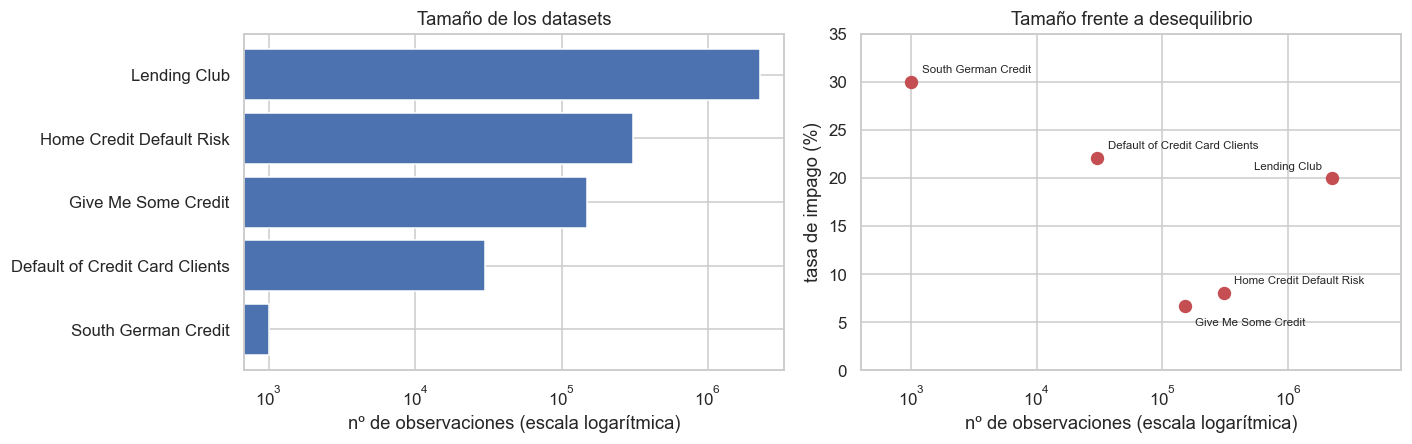

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.2))

orden = tabla_datasets.sort_values("muestras").index
axes[0].barh(orden, tabla_datasets.loc[orden, "muestras"].astype(float), color="#4C72B0")
axes[0].set_xscale("log")
axes[0].set(xlabel="nº de observaciones (escala logarítmica)", title="Tamaño de los datasets")

# Desplazamiento de cada etiqueta para que no se solapen entre sí
ETIQUETAS = {
    "Give Me Some Credit": (7, -13, "left"),
    "Home Credit Default Risk": (7, 6, "left"),
    "Lending Club": (-7, 6, "right"),
    "Default of Credit Card Clients": (7, 6, "left"),
    "South German Credit": (7, 6, "left"),
}
for nombre in tabla_datasets.index:
    x = float(tabla_datasets.loc[nombre, "muestras"])
    y = float(tabla_datasets.loc[nombre, "tasa_impago_%"])
    dx, dy, ha = ETIQUETAS[nombre]
    axes[1].scatter(x, y, s=60, color="#C44E52")
    axes[1].annotate(nombre, (x, y), fontsize=7.5, xytext=(dx, dy), textcoords="offset points", ha=ha)
axes[1].set_xscale("log")
axes[1].set(xlabel="nº de observaciones (escala logarítmica)", ylabel="tasa de impago (%)",
            title="Tamaño frente a desequilibrio")
axes[1].set_xlim(4e2, 8e6)
axes[1].set_ylim(0, 35)

plt.tight_layout()
plt.show()

<a id="s7"></a>
## 7. Fichas para el informe

Los datos de los apartados anteriores, ya formateados, tal como se recogen en el informe de
datasets. Todo lo que aparece aquí sale de los ficheros descargados.

In [36]:
def imprimir_ficha(nombre: str, datos: dict) -> str:
    ancho = max(len(k) for k in datos)
    lineas = [nombre, "=" * len(nombre)]
    for campo, valor in datos.items():
        lineas.append(f"{campo + ':':<{ancho + 2}} {valor}")
    return "\n".join(lineas)


fichas_texto = "\n\n".join(imprimir_ficha(n, d) for n, d in FICHAS.items())
print(fichas_texto)

Give Me Some Credit
Nº de muestras:     150.000 clientes etiquetados en cs-training.csv; cs-test.csv tiene 101.503 filas sin etiqueta
Nº de variables:    10 predictoras, todas numéricas
Variable objetivo:  SeriousDlqin2yrs; se considera impago el valor 1
Tasa de impago:     6,7 % (10.026 de 150.000 clientes)
Desequilibrio:      14,0 clientes sin impago por cada uno con impago
Valores perdidos:   MonthlyIncome (29.731 filas, 19,8 %), NumberOfDependents (3.924 filas, 2,6 %)
Ficheros:           cs-test.csv, cs-training.csv, Data Dictionary.xls, sampleEntry.csv
Filas duplicadas:   609
Anomalías:          edad 0 en 1 fila; RevolvingUtilizationOfUnsecuredLines llega a 50.708, con 241 filas por encima de 10 (pasar de 1 es legítimo y ocurre en 3.321); DebtRatio no es un cociente en las 29.731 filas sin MonthlyIncome, donde su mediana es 1.159 y el 100 % de los valores son enteros, frente a 0,30 y 3,6 % en el resto; códigos 96 y 98 a la vez en las tres variables de retraso en 269 filas

South G